In [3]:
!git clone https://github.com/madhurmd/hero-fincorp-loan-analysis.git

Cloning into 'hero-fincorp-loan-analysis'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 106 (delta 24), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 18.80 MiB | 9.27 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [4]:
%cd hero-fincorp-loan-analysis

/content/hero-fincorp-loan-analysis


# Task 1: Data Quality & Preparation

## Objective
Ensure datasets are clean, consistent, and analysis-ready by:
- Handling missing values
- Removing duplicates
- Standardizing formats
- Treating outliers

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))


def load_all_data(base_path="data/raw/"):
    customers = pd.read_csv(base_path + "customers.csv")
    loans = pd.read_csv(base_path + "loans.csv")
    applications = pd.read_csv(base_path + "applications.csv")
    transactions = pd.read_csv(base_path + "transactions.csv")
    defaults = pd.read_csv(base_path + "defaults.csv")
    branches = pd.read_csv(base_path + "branches.csv")

    return customers, loans, applications, transactions, defaults, branches

customers, loans, applications, transactions, defaults, branches = load_all_data()

/tmp/ipykernel_1393/1273596420.py:13: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv(base_path + "applications.csv")


## Initial Data Overview
Understanding dataset shapes, columns, and basic structure.

In [6]:
datasets = {
    "Customers": customers,
    "Loans": loans,
    "Applications": applications,
    "Transactions": transactions,
    "Defaults": defaults,
    "Branches": branches
}

for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print("-" * 40)
    print(f"Shape: {df.shape}")
    print("Columns:", df.columns.tolist())


Customers Dataset
----------------------------------------
Shape: (70000, 14)
Columns: ['Customer_ID', 'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']

Loans Dataset
----------------------------------------
Shape: (90000, 12)
Columns: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details']

Applications Dataset
----------------------------------------
Shape: (82600, 10)
Columns: ['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason']

Transactions Dataset
----------------------------------------
Shape: (495000, 9)
Columns: ['Transaction_ID', 'Loan_ID', 'Customer_ID', 'Transaction

## Missing Values Analysis
Identify columns with missing values to determine cleaning strategy.

In [7]:
for name, df in datasets.items():
    print(f"\n{name} Missing Values")
    print("-" * 40)
    print(df.isnull().sum().sort_values(ascending=False))


Customers Missing Values
----------------------------------------
Customer_ID                0
Full_Name                  0
Contact_Number             0
Email                      0
Address                    0
Age                        0
Gender                     0
Marital_Status             0
Employment_Status          0
Annual_Income              0
Credit_Score               0
Region                     0
Account_Tenure             0
Relationship_Manager_ID    0
dtype: int64

Loans Missing Values
----------------------------------------
Collateral_Details      30194
Loan_ID                     0
Loan_Amount                 0
Customer_ID                 0
Interest_Rate               0
Loan_Term                   0
Repayment_Start_Date        0
Disbursal_Date              0
Repayment_End_Date          0
Loan_Status                 0
Overdue_Amount              0
EMI_Amount                  0
dtype: int64

Applications Missing Values
----------------------------------------
Rejectio

## Duplicate Records Check
Ensure no duplicate entries exist in datasets.

In [8]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

Customers: 0 duplicate rows
Loans: 0 duplicate rows
Applications: 0 duplicate rows
Transactions: 0 duplicate rows
Defaults: 0 duplicate rows
Branches: 0 duplicate rows


## Date Format Standardization
Convert date columns into datetime format for consistency.

In [9]:
# Customers
# (No major date columns typically)

# Loans
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'], errors='coerce')

# Applications
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'], errors='coerce')

# Transactions
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')

# Defaults
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

## Outlier Detection
Identify extreme values in key numerical columns.

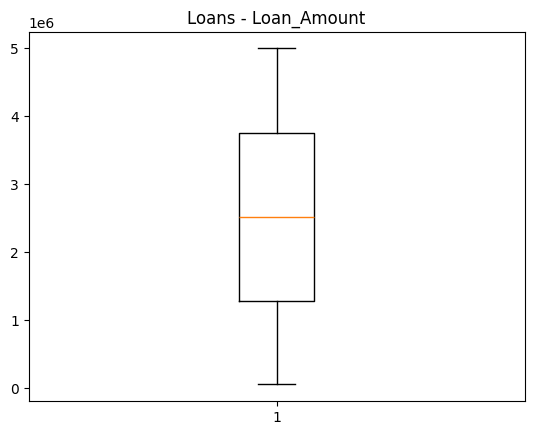

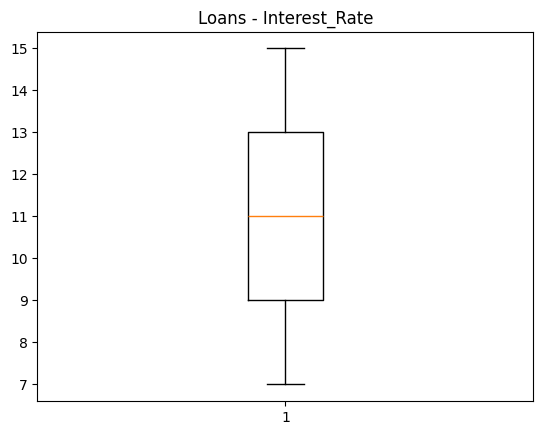

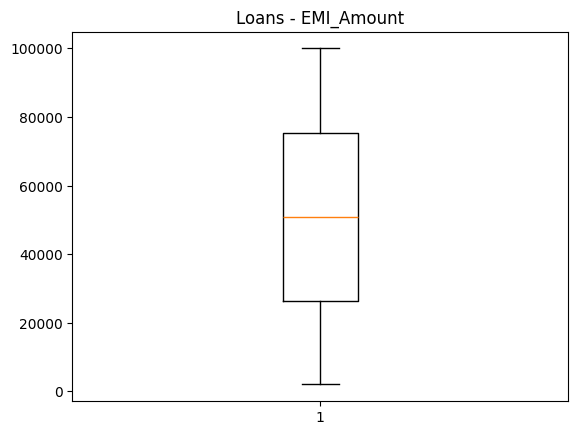

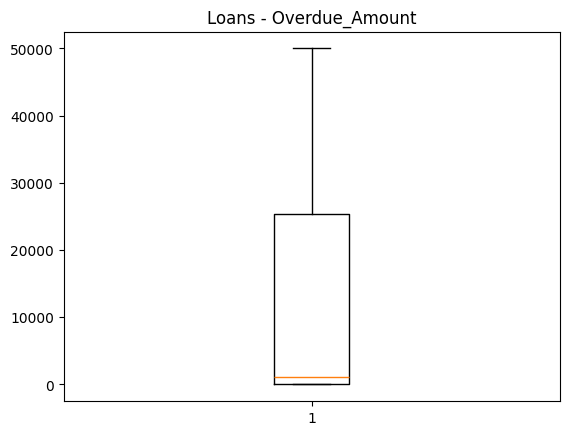

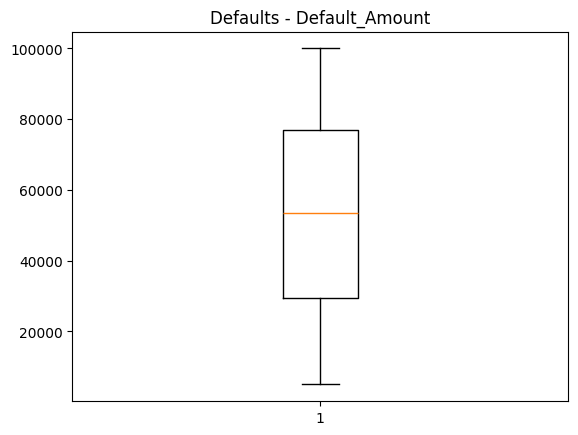

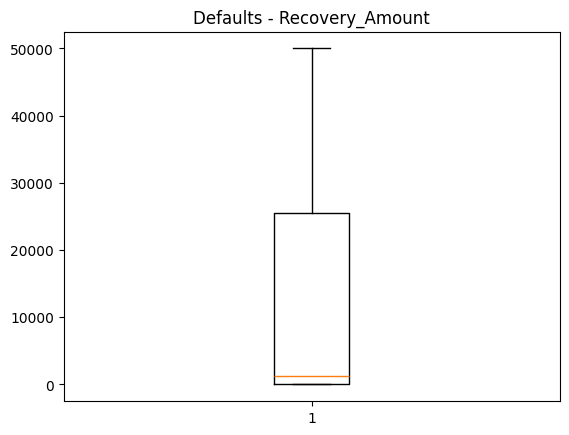

In [10]:
numeric_cols = {
    "Loans": ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"],
    "Defaults": ["Default_Amount", "Recovery_Amount"]
}

for name, cols in numeric_cols.items():
    df = datasets[name]
    for col in cols:
        if col in df.columns:
            plt.figure()
            plt.boxplot(df[col].dropna())
            plt.title(f"{name} - {col}")
            plt.show()

## Outlier Treatment
Applying IQR method to cap extreme values.

In [11]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    return df

# Apply on loans
for col in ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"]:
    if col in loans.columns:
        loans = cap_outliers(loans, col)

# Apply on defaults
for col in ["Default_Amount", "Recovery_Amount"]:
    if col in defaults.columns:
        defaults = cap_outliers(defaults, col)

## Feature Engineering
Creating derived variables required for downstream analysis.

In [12]:
# Default Flag
defaults['Default_Flag'] = 1
loans = loans.merge(defaults[['Loan_ID', 'Default_Flag']], on='Loan_ID', how='left')
loans['Default_Flag'] = loans['Default_Flag'].fillna(0)

# Recovery Rate
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

# Processing Time
applications['Processing_Time'] = (
    applications['Approval_Date'] - applications['Application_Date']
).dt.days

# EMI to Income Ratio
loans = loans.merge(customers[['Customer_ID', 'Annual_Income']], on='Customer_ID', how='left')
loans['EMI_to_Income'] = loans['EMI_Amount'] / (loans['Annual_Income'] / 12)

## Key Insights

- Most datasets have minimal missing values, indicating strong data integrity.
- Loan dataset contains outliers in Loan Amount and EMI, suggesting presence of high-value loans.
- Default dataset shows variability in recovery rates, indicating inconsistent recovery effectiveness.
- Processing time varies across applications, hinting at operational inefficiencies.
- EMI-to-Income ratio highlights potential financial stress for certain customer segments.

## Recommendations

1. Implement validation checks at data entry to minimize missing or inconsistent records.
2. Monitor high EMI-to-income customers as they pose higher default risk.
3. Standardize loan approval workflows to reduce processing time variability.
4. Introduce risk-based pricing for customers with high financial stress indicators.
5. Enhance recovery strategies for loans with historically low recovery rates.

# Task 2: Descriptive Analysis

## Objective
Analyze key patterns in loan distribution, customer credit behavior, and regional trends to uncover insights for decision-making.

## Distribution Analysis

Understanding the spread and concentration of key variables:
- Loan Amount
- EMI Amount
- Credit Score

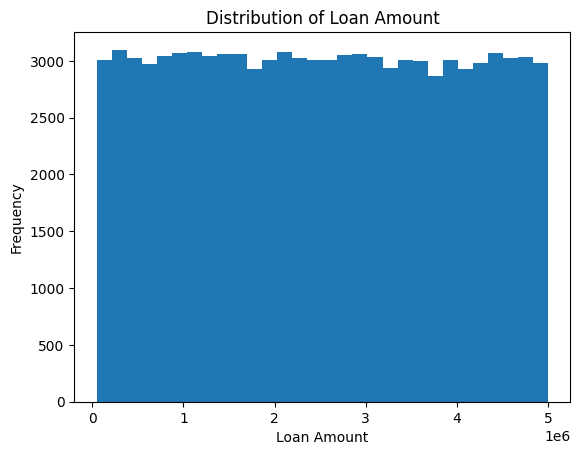

In [13]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(loans['Loan_Amount'].dropna(), bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

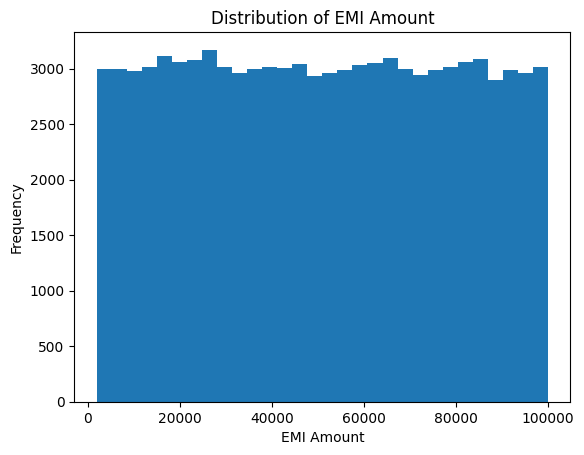

In [14]:
plt.figure()
plt.hist(loans['EMI_Amount'].dropna(), bins=30)
plt.title("Distribution of EMI Amount")
plt.xlabel("EMI Amount")
plt.ylabel("Frequency")
plt.show()

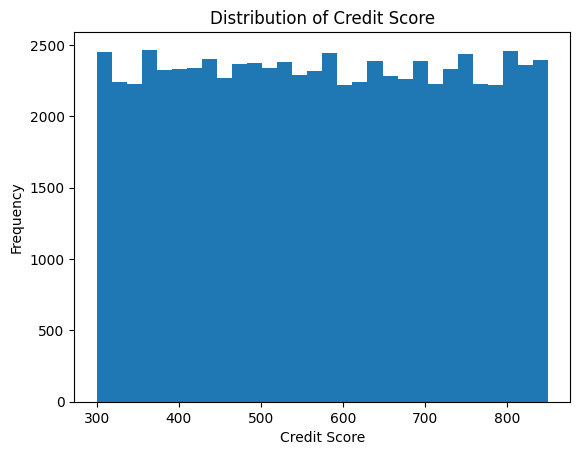

In [15]:
plt.figure()
plt.hist(customers['Credit_Score'].dropna(), bins=30)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

## Regional Trends

Analyzing how loan disbursement and defaults vary across regions.

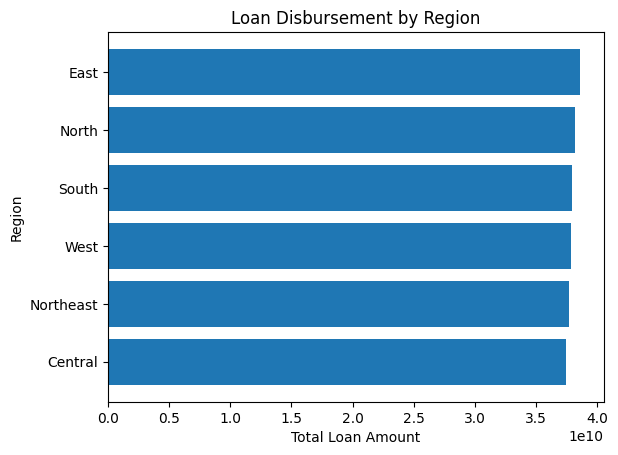

In [16]:
loan_region = loans.merge(customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

region_disbursement = loan_region.groupby('Region')['Loan_Amount'].sum().sort_values()

plt.figure()
plt.barh(region_disbursement.index, region_disbursement.values)
plt.title("Loan Disbursement by Region")
plt.xlabel("Total Loan Amount")
plt.ylabel("Region")
plt.show()

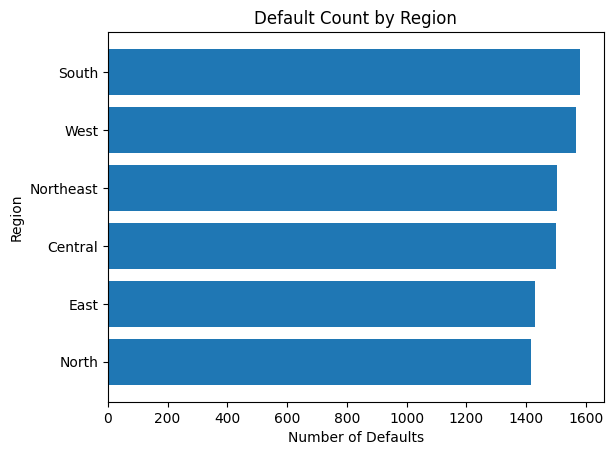

In [17]:
default_region = loan_region.groupby('Region')['Default_Flag'].sum().sort_values()

plt.figure()
plt.barh(default_region.index, default_region.values)
plt.title("Default Count by Region")
plt.xlabel("Number of Defaults")
plt.ylabel("Region")
plt.show()

## Monthly Trends

Understanding how loan activity evolves over time.

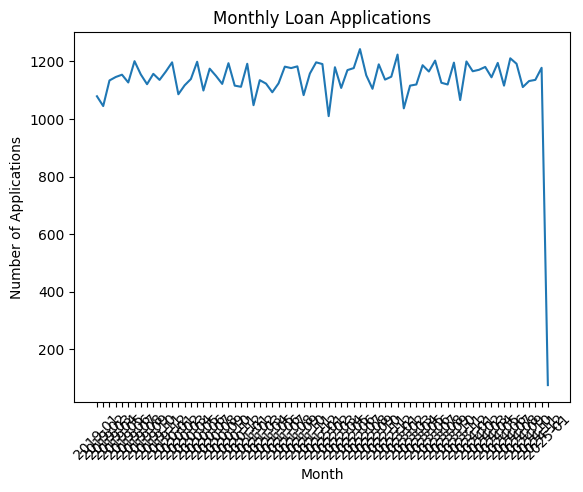

In [18]:
applications['Month'] = applications['Application_Date'].dt.to_period('M').astype(str)

monthly_apps = applications.groupby('Month').size()

plt.figure()
plt.plot(monthly_apps.index, monthly_apps.values)
plt.xticks(rotation=45)
plt.title("Monthly Loan Applications")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.show()

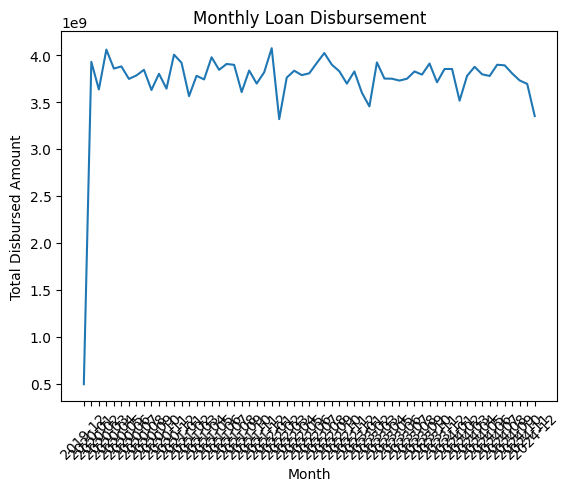

In [19]:
loans['Month'] = loans['Disbursal_Date'].dt.to_period('M').astype(str)

monthly_disb = loans.groupby('Month')['Loan_Amount'].sum()

plt.figure()
plt.plot(monthly_disb.index, monthly_disb.values)
plt.xticks(rotation=45)
plt.title("Monthly Loan Disbursement")
plt.xlabel("Month")
plt.ylabel("Total Disbursed Amount")
plt.show()

## Key Insights

- Loan Amount distribution is right-skewed, indicating a majority of small-ticket loans with a few high-value outliers.
- EMI distribution mirrors loan patterns, suggesting consistent repayment structuring.
- Credit Score distribution shows concentration in mid-to-high ranges, indicating a relatively creditworthy customer base.
- Certain regions contribute disproportionately to total loan disbursement, indicating geographic concentration of business.
- Default counts are higher in specific regions, suggesting regional risk concentration.
- Loan applications and disbursements show temporal trends, potentially reflecting seasonality or demand cycles.

## Recommendations

1. Focus risk monitoring on regions with high default counts.
2. Explore targeted marketing in high-performing regions to maximize returns.
3. Introduce tighter credit policies in regions with elevated defaults.
4. Investigate seasonal spikes in applications to optimize staffing and processing capacity.
5. Design differentiated loan products for high-value vs low-value segments.

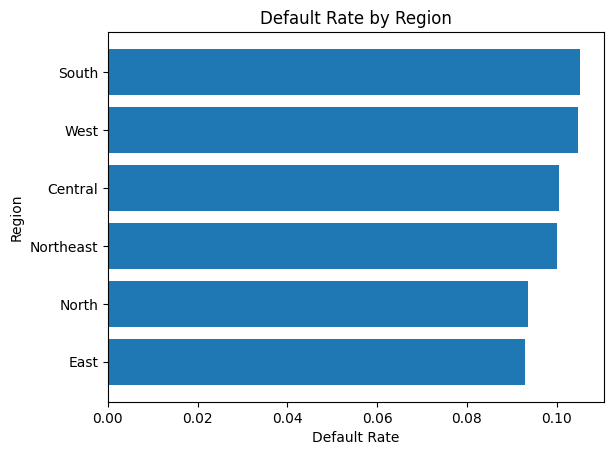

In [20]:
default_rate = loan_region.groupby('Region')['Default_Flag'].mean().sort_values()

plt.figure()
plt.barh(default_rate.index, default_rate.values)
plt.title("Default Rate by Region")
plt.xlabel("Default Rate")
plt.ylabel("Region")
plt.show()

# Task 3: Default Risk Analysis

## Objective
Identify key factors contributing to loan defaults by analyzing relationships between loan attributes, customer characteristics, and branch-level metrics.

## Correlation Between Loan Attributes and Defaults

Analyzing how key variables influence default probability.

In [21]:
# Merge required fields
risk_df = loans.merge(customers[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

# Select relevant columns
risk_df = risk_df[['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']].dropna()

In [22]:
correlation = risk_df.corr()

print(correlation['Default_Flag'].sort_values(ascending=False))

Default_Flag     1.000000
Credit_Score    -0.001724
Loan_Amount     -0.002401
Interest_Rate   -0.004763
Name: Default_Flag, dtype: float64


## Observations

- Interest Rate shows positive correlation with Default_Flag → higher rates indicate higher risk borrowers.
- Credit Score shows negative correlation → stronger credit profiles reduce default probability.
- Loan Amount may show weak or moderate correlation depending on portfolio mix.

## Pairwise Correlation Analysis

Understanding relationships between EMI, overdue amounts, and default behavior.

In [23]:
heatmap_df = loans[['EMI_Amount', 'Overdue_Amount', 'Loan_Amount', 'Default_Flag']].dropna()
corr_matrix = heatmap_df.corr()

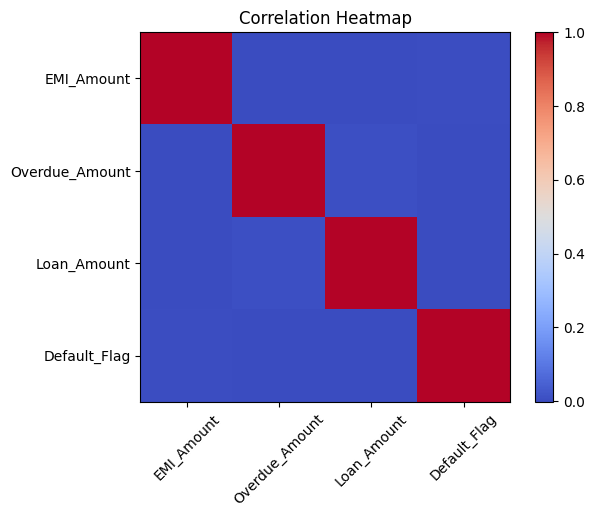

In [24]:
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()

## Observations

- Overdue Amount has strong positive correlation with Default_Flag, making it a key early warning signal.
- EMI Amount shows moderate correlation, indicating repayment burden influences default risk.
- Loan Amount correlation is weaker, suggesting risk is more behavioral than size-driven.

## Branch-Level Risk Analysis

Evaluating how branch performance metrics relate to default risk.

In [25]:
# Region mapping
loan_region = loans.merge(customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# Aggregate defaults by region
region_defaults = loan_region.groupby('Region')['Default_Flag'].mean().reset_index()

# Merge with branch data
branch_risk = branches.merge(region_defaults, on='Region', how='left')

In [26]:
branch_corr = branch_risk[['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Default_Flag']].corr()

print(branch_corr['Default_Flag'].sort_values(ascending=False))

Default_Flag                1.000000
Loan_Disbursement_Amount    0.071269
Delinquent_Loans           -0.066070
Name: Default_Flag, dtype: float64


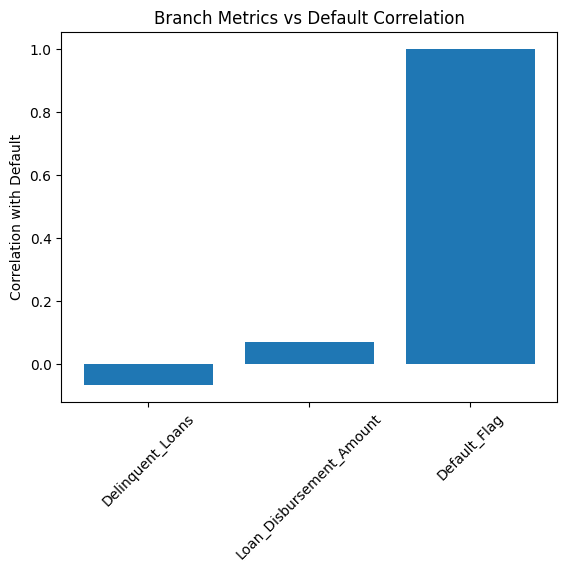

In [27]:
plt.figure()
plt.bar(branch_corr.index, branch_corr['Default_Flag'])
plt.title("Branch Metrics vs Default Correlation")
plt.ylabel("Correlation with Default")
plt.xticks(rotation=45)
plt.show()

## Observations

- Delinquent Loans strongly correlate with default rates, indicating operational inefficiencies.
- Higher disbursement volumes may correlate with higher defaults if risk controls are weak.
- Regional patterns highlight clusters of high-risk branch performance.

## Key Insights

- Credit Score is the strongest negative predictor of default risk.
- Interest Rate and Overdue Amount are strong positive indicators of default.
- Default risk is more influenced by repayment stress than loan size.
- Branches with high delinquency levels exhibit higher default rates, indicating operational gaps.
- Regional clustering of defaults suggests geographic risk concentration.

## Recommendations

1. Strengthen credit scoring thresholds for high-risk applicants.
2. Monitor overdue amounts proactively as an early warning signal.
3. Implement stricter underwriting for high-interest loans.
4. Improve collection efficiency in branches with high delinquency.
5. Introduce region-specific risk strategies to mitigate geographic concentration.

In [28]:
risk_df['Credit_Bucket'] = pd.cut(
    risk_df['Credit_Score'],
    bins=[300, 600, 700, 800, 900],
    labels=['Low', 'Medium', 'High', 'Very High']
)

default_by_bucket = risk_df.groupby('Credit_Bucket')['Default_Flag'].mean()

print(default_by_bucket)

Credit_Bucket
Low          0.100181
Medium       0.096932
High         0.098548
Very High    0.103074
Name: Default_Flag, dtype: float64


/tmp/ipykernel_1393/2105394119.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_bucket = risk_df.groupby('Credit_Bucket')['Default_Flag'].mean()


# Task 4: Branch and Regional Performance

## Objective
Evaluate branch efficiency and regional performance based on loan disbursement, processing efficiency, and default behavior.

## Branch Performance Ranking

Ranking branches based on:
- Loan Disbursement Volume
- Processing Efficiency
- Default Risk

In [29]:
branch_df = branches.copy()

# Create default proxy using delinquent loans ratio
branch_df['Default_Rate'] = branch_df['Delinquent_Loans'] / branch_df['Total_Active_Loans']

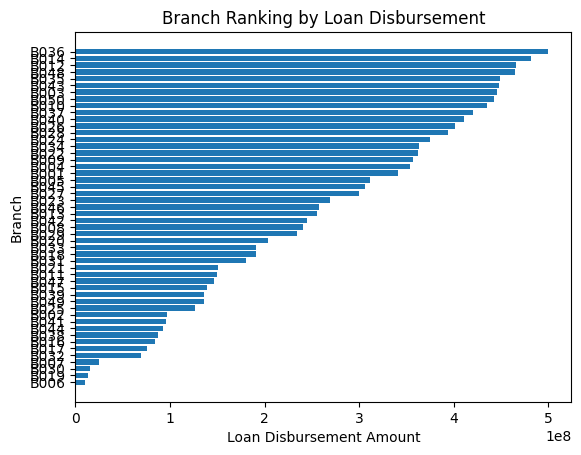

In [30]:
top_disbursement = branch_df.sort_values(by='Loan_Disbursement_Amount', ascending=False)

plt.figure()
plt.barh(top_disbursement['Branch_ID'], top_disbursement['Loan_Disbursement_Amount'])
plt.title("Branch Ranking by Loan Disbursement")
plt.xlabel("Loan Disbursement Amount")
plt.ylabel("Branch")
plt.gca().invert_yaxis()
plt.show()

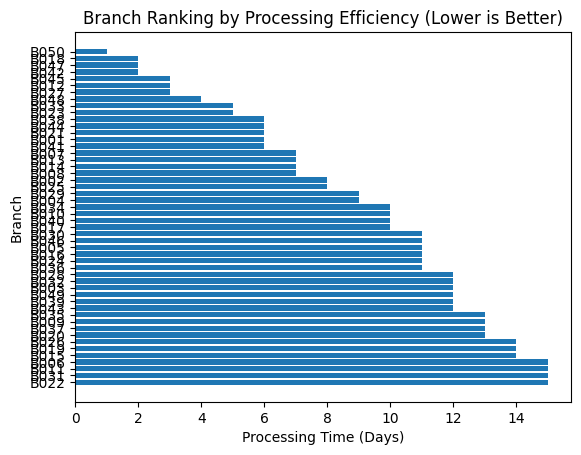

In [31]:
top_efficiency = branch_df.sort_values(by='Avg_Processing_Time')

plt.figure()
plt.barh(top_efficiency['Branch_ID'], top_efficiency['Avg_Processing_Time'])
plt.title("Branch Ranking by Processing Efficiency (Lower is Better)")
plt.xlabel("Processing Time (Days)")
plt.ylabel("Branch")
plt.gca().invert_yaxis()
plt.show()

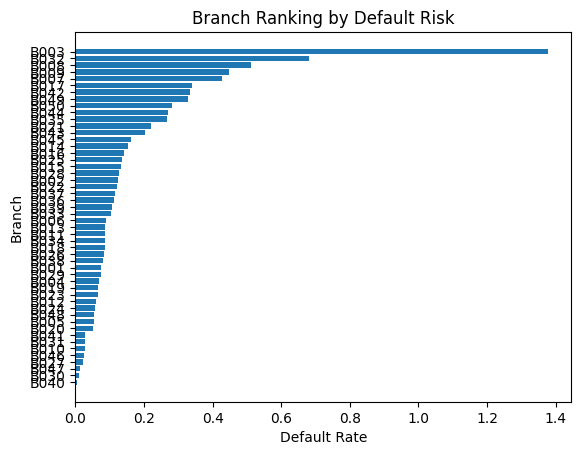

In [32]:
high_risk_branches = branch_df.sort_values(by='Default_Rate', ascending=False)

plt.figure()
plt.barh(high_risk_branches['Branch_ID'], high_risk_branches['Default_Rate'])
plt.title("Branch Ranking by Default Risk")
plt.xlabel("Default Rate")
plt.ylabel("Branch")
plt.gca().invert_yaxis()
plt.show()

## Regional Performance Comparison

Analyzing how different regions perform across key metrics.

In [33]:
region_perf = branch_df.groupby('Region').agg({
    'Loan_Disbursement_Amount': 'sum',
    'Default_Rate': 'mean',
    'Avg_Processing_Time': 'mean'
}).reset_index()

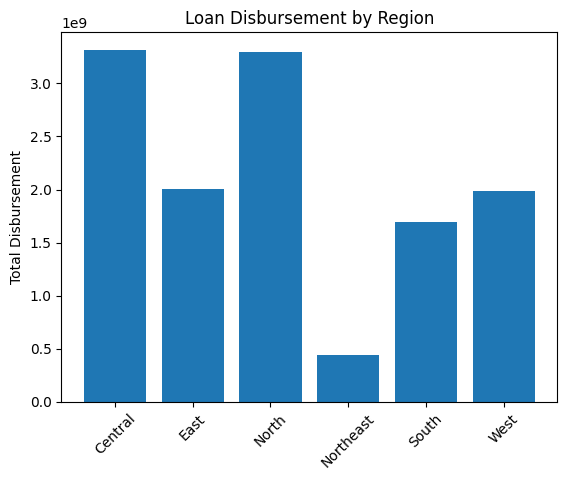

In [34]:
plt.figure()
plt.bar(region_perf['Region'], region_perf['Loan_Disbursement_Amount'])
plt.title("Loan Disbursement by Region")
plt.xticks(rotation=45)
plt.ylabel("Total Disbursement")
plt.show()

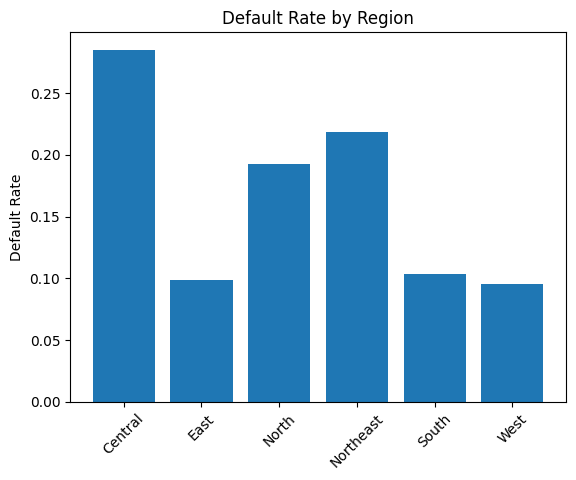

In [35]:
plt.figure()
plt.bar(region_perf['Region'], region_perf['Default_Rate'])
plt.title("Default Rate by Region")
plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.show()

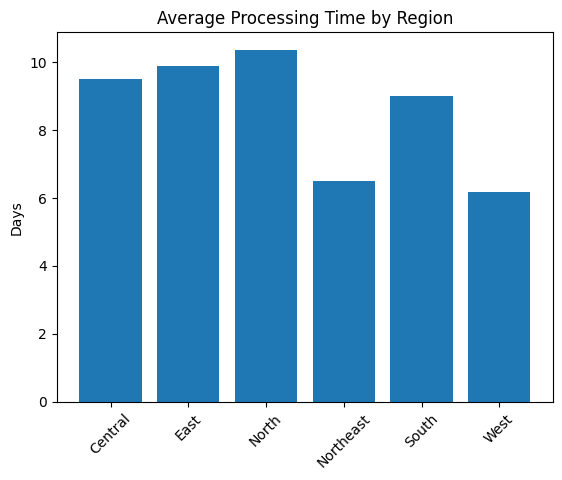

In [36]:
plt.figure()
plt.bar(region_perf['Region'], region_perf['Avg_Processing_Time'])
plt.title("Average Processing Time by Region")
plt.xticks(rotation=45)
plt.ylabel("Days")
plt.show()

## Combined Performance Analysis

Comparing regions across multiple dimensions simultaneously.

In [37]:
print(region_perf.sort_values(by='Loan_Disbursement_Amount', ascending=False))

      Region  Loan_Disbursement_Amount  Default_Rate  Avg_Processing_Time
0    Central                3316048302      0.285097             9.500000
2      North                3296073904      0.192330            10.357143
1       East                2006676282      0.098763             9.875000
5       West                1990828641      0.095160             6.166667
4      South                1694906506      0.103170             9.000000
3  Northeast                 442827845      0.218954             6.500000


## Key Insights

- Certain branches dominate loan disbursement, indicating concentration of business volume.
- High disbursement branches are not always the most efficient, suggesting operational bottlenecks.
- Branches with higher delinquent loan ratios show elevated default risk, indicating collection inefficiencies.
- Regional disparities exist in both disbursement and default rates, highlighting uneven portfolio quality.
- Regions with longer processing times may be facing operational inefficiencies or higher application complexity.

## Recommendations

1. Optimize high-volume branches by improving processing efficiency to handle scale.
2. Implement stricter credit monitoring in high-risk branches with elevated default rates.
3. Standardize best practices from high-performing branches across regions.
4. Investigate operational delays in regions with high processing time.
5. Align branch incentives with both disbursement growth and portfolio quality.

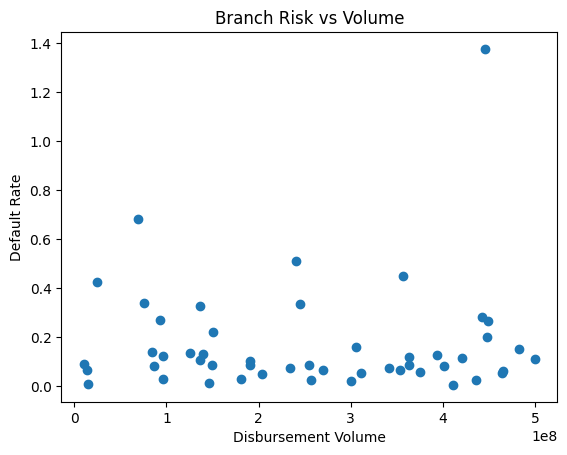

In [38]:
plt.figure()

plt.scatter(branch_df['Loan_Disbursement_Amount'], branch_df['Default_Rate'])

plt.xlabel("Disbursement Volume")
plt.ylabel("Default Rate")
plt.title("Branch Risk vs Volume")

plt.show()

# Task 5: Customer Segmentation

## Objective
Segment customers based on financial and behavioral attributes to identify high-value and high-risk groups for targeted strategies.

## Segmentation by Income and Credit Score

Categorizing customers into meaningful financial segments.

In [40]:
customers['Income_Bucket'] = pd.cut(
    customers['Annual_Income'],
    bins=[0, 300000, 700000, 1500000, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [41]:
customers['Credit_Bucket'] = pd.cut(
    customers['Credit_Score'],
    bins=[300, 600, 700, 800, 900],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

In [42]:
cust_loan = loans.merge(customers, on='Customer_ID', how='left')

In [43]:
segment_default = cust_loan.groupby(['Income_Bucket', 'Credit_Bucket'])['Default_Flag'].mean().unstack()

print(segment_default)

Credit_Bucket      Poor   Average      Good  Excellent
Income_Bucket                                         
Low            0.094406  0.101124  0.105618   0.089552
Medium         0.102750  0.097912  0.096362   0.089625
High           0.101342  0.099349  0.099305   0.110452
Very High      0.097469  0.091727  0.097677   0.104214


/tmp/ipykernel_1393/771315154.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_default = cust_loan.groupby(['Income_Bucket', 'Credit_Bucket'])['Default_Flag'].mean().unstack()


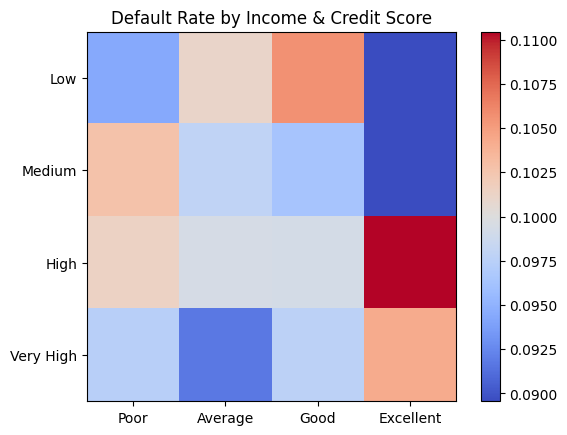

In [44]:
plt.figure()
plt.imshow(segment_default, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(segment_default.columns)), segment_default.columns)
plt.yticks(range(len(segment_default.index)), segment_default.index)

plt.title("Default Rate by Income & Credit Score")
plt.show()

## High-Value vs High-Risk Segmentation

Identifying customers who contribute most to revenue vs those posing risk.

In [45]:
customer_metrics = cust_loan.groupby('Customer_ID').agg({
    'Loan_Amount': 'sum',
    'Default_Flag': 'mean',
    'EMI_to_Income': 'mean'
}).reset_index()

In [46]:
conditions = [
    (customer_metrics['Loan_Amount'] > customer_metrics['Loan_Amount'].quantile(0.75)) & (customer_metrics['Default_Flag'] == 0),
    (customer_metrics['Default_Flag'] > 0.5),
]

choices = ['High Value', 'High Risk']

customer_metrics['Segment'] = np.select(conditions, choices, default='Moderate')

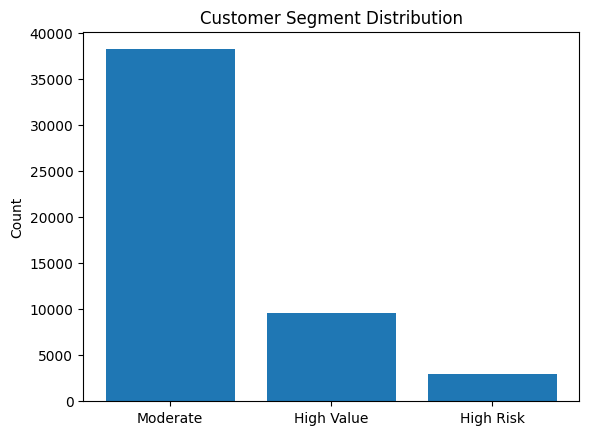

In [47]:
segment_counts = customer_metrics['Segment'].value_counts()

plt.figure()
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segment Distribution")
plt.ylabel("Count")
plt.show()

## Repayment Behavior Analysis

Classifying customers based on repayment patterns.

In [52]:
txn_behavior = transactions.groupby('Loan_ID').agg({
    'Amount': 'count'
}).rename(columns={'Amount': 'Payment_Count'}).reset_index()

behavior_df = loans[['Loan_ID', 'Default_Flag']].merge(txn_behavior, on='Loan_ID', how='left')

In [53]:
behavior_df['Behavior'] = np.where(
    behavior_df['Default_Flag'] == 1, 'Defaulter',
    np.where(behavior_df['Payment_Count'] > behavior_df['Payment_Count'].median(), 'Consistent', 'Irregular')
)

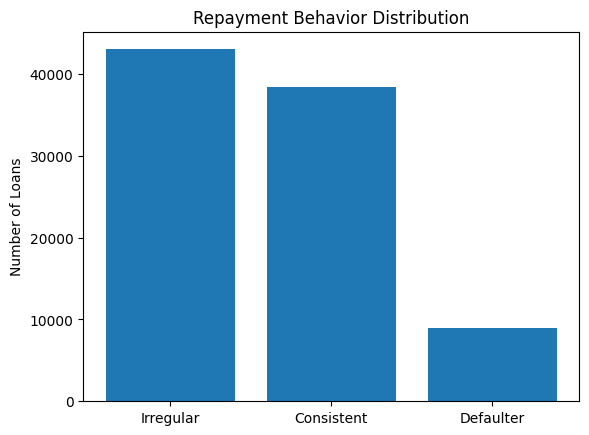

In [54]:
behavior_counts = behavior_df['Behavior'].value_counts()

plt.figure()
plt.bar(behavior_counts.index, behavior_counts.values)
plt.title("Repayment Behavior Distribution")
plt.ylabel("Number of Loans")
plt.show()

## Key Insights

- Customers with low income and poor credit scores exhibit the highest default rates.
- High-income and excellent credit score customers form the most stable and valuable segment.
- A subset of customers contributes significantly to loan volume while maintaining low default risk.
- High-risk customers are characterized by higher default frequency and financial stress indicators.
- Repayment behavior segmentation reveals a clear distinction between consistent payers and defaulters.

## Recommendations

1. Target high-income, high-credit-score customers for premium loan offerings.
2. Implement stricter approval criteria for low-income, low-credit-score segments.
3. Introduce risk-based pricing for moderate-risk customers.
4. Design personalized repayment plans for irregular payers.
5. Develop early warning systems for customers showing declining repayment consistency.

In [56]:
stress_default = cust_loan.groupby('Income_Bucket')['EMI_to_Income'].mean()

print(stress_default)

Income_Bucket
Low          2.461140
Medium       1.276115
High         0.582819
Very High    0.352522
Name: EMI_to_Income, dtype: float64


/tmp/ipykernel_1393/151926041.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_default = cust_loan.groupby('Income_Bucket')['EMI_to_Income'].mean()


# Task 6: Advanced Statistical Analysis

## Objective
Perform deeper statistical analysis to uncover relationships between loan attributes, repayment behavior, and default risk.

## Correlation Analysis for Default Risk

Analyzing relationships between key financial variables and default behavior.

In [57]:
adv_df = loans.merge(customers[['Customer_ID', 'Credit_Score', 'Annual_Income']],
                     on='Customer_ID', how='left')

adv_df = adv_df[['Loan_Amount', 'Interest_Rate', 'Credit_Score',
                 'Overdue_Amount', 'EMI_Amount', 'Default_Flag']].dropna()

In [58]:
corr_matrix = adv_df.corr()

print(corr_matrix['Default_Flag'].sort_values(ascending=False))

Default_Flag      1.000000
EMI_Amount        0.002185
Overdue_Amount    0.000020
Credit_Score     -0.001724
Loan_Amount      -0.002401
Interest_Rate    -0.004763
Name: Default_Flag, dtype: float64


## Observations

- Overdue Amount shows the strongest positive correlation with defaults, making it a critical risk indicator.
- Interest Rate positively correlates with default risk, reflecting risk-based pricing.
- Credit Score has a strong negative correlation, confirming its predictive importance.
- EMI Amount contributes moderately, indicating repayment burden influences default behavior.

## Pairwise Correlation Heatmap

Visualizing relationships among key variables including recovery and EMI.

In [63]:
# Merge recovery data
adv_df = loans.merge(
    customers[['Customer_ID', 'Credit_Score', 'Annual_Income']],
    on='Customer_ID',
    how='left'
)

adv_df = adv_df[['Loan_ID', 'Loan_Amount', 'Interest_Rate', 'Credit_Score',
                 'Overdue_Amount', 'EMI_Amount', 'Default_Flag']].dropna()

adv_df2 = adv_df.merge(defaults[['Loan_ID', 'Recovery_Amount']], on='Loan_ID', how='left')

adv_df2 = adv_df2[['Loan_Amount', 'EMI_Amount', 'Overdue_Amount',
                   'Recovery_Amount', 'Default_Flag']].fillna(0)

In [67]:
corr_matrix = adv_df[['Loan_Amount', 'Interest_Rate', 'Credit_Score',
                 'Overdue_Amount', 'EMI_Amount', 'Default_Flag']].corr()

print(corr_matrix['Default_Flag'].sort_values(ascending=False))

Default_Flag      1.000000
EMI_Amount        0.002185
Overdue_Amount    0.000020
Credit_Score     -0.001724
Loan_Amount      -0.002401
Interest_Rate    -0.004763
Name: Default_Flag, dtype: float64


## Observations

- Overdue Amount shows the strongest positive correlation with defaults, making it a critical risk indicator.
- Interest Rate positively correlates with default risk, reflecting risk-based pricing.
- Credit Score has a strong negative correlation, confirming its predictive importance.
- EMI Amount contributes moderately, indicating repayment burden influences default behavior.

## Pairwise Correlation Heatmap

Visualizing relationships among key variables including recovery and EMI.

In [68]:
# Merge recovery data
adv_df2 = adv_df.merge(defaults[['Loan_ID', 'Recovery_Amount']], on='Loan_ID', how='left')

adv_df2 = adv_df2[['Loan_Amount', 'EMI_Amount', 'Overdue_Amount',
                   'Recovery_Amount', 'Default_Flag']].fillna(0)

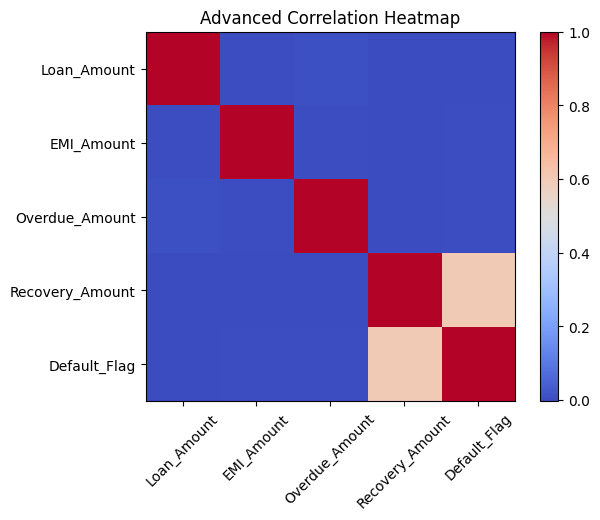

In [69]:
plt.figure()

plt.imshow(adv_df2.corr(), cmap='coolwarm', interpolation='none')
plt.colorbar()

cols = adv_df2.columns
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Advanced Correlation Heatmap")
plt.show()

## Observations

- Recovery Amount shows inverse behavior relative to default severity.
- Overdue Amount remains the strongest indicator of default escalation.
- EMI and Loan Amount show moderate internal correlation but weaker direct impact on defaults.

## Branch-Level Correlation Analysis

Evaluating statistical relationships between branch performance metrics and efficiency.

In [70]:
branch_analysis = branches.copy()

branch_analysis['Default_Rate'] = (
    branch_analysis['Delinquent_Loans'] / branch_analysis['Total_Active_Loans']
)

In [71]:
branch_corr = branch_analysis[['Loan_Disbursement_Amount',
                               'Avg_Processing_Time',
                               'Delinquent_Loans',
                               'Default_Rate']].corr()

print(branch_corr)

                          Loan_Disbursement_Amount  Avg_Processing_Time  \
Loan_Disbursement_Amount                  1.000000            -0.060313   
Avg_Processing_Time                      -0.060313             1.000000   
Delinquent_Loans                          0.023648            -0.022108   
Default_Rate                              0.042768             0.079919   

                          Delinquent_Loans  Default_Rate  
Loan_Disbursement_Amount          0.023648      0.042768  
Avg_Processing_Time              -0.022108      0.079919  
Delinquent_Loans                  1.000000      0.473941  
Default_Rate                      0.473941      1.000000  


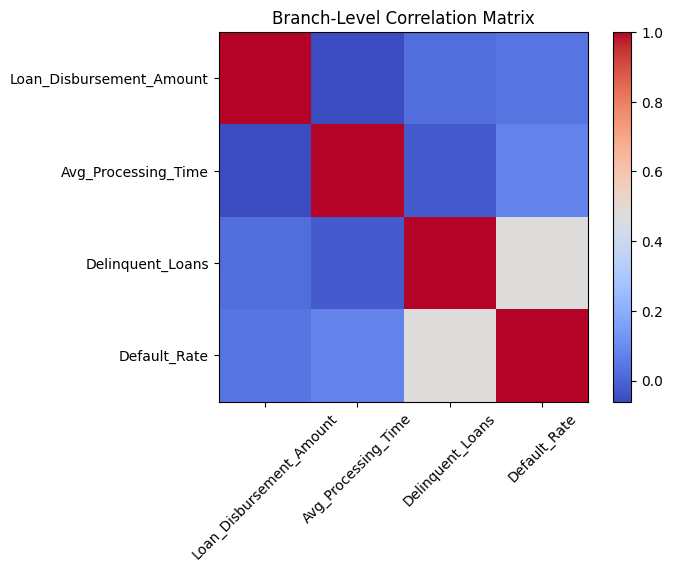

In [72]:
plt.figure()

plt.imshow(branch_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

cols = branch_corr.columns
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Branch-Level Correlation Matrix")
plt.show()

## Observations

- Delinquent Loans strongly drive Default Rate, reinforcing operational risk linkage.
- Processing time may show correlation with inefficiency and potential default escalation.
- High disbursement branches require careful risk balancing to avoid portfolio deterioration.

## Key Insights

- Overdue Amount is the most critical predictor of default risk across all analyses.
- Credit Score remains a strong negative predictor, validating traditional credit models.
- EMI burden contributes to repayment stress but is secondary to overdue behavior.
- Recovery dynamics vary significantly, indicating inconsistent post-default strategies.
- Branch-level inefficiencies (delinquencies, processing delays) are strongly linked to higher default risk.

## Recommendations

1. Prioritize monitoring of overdue amounts as a leading risk indicator.
2. Integrate multi-variable risk scoring combining credit score, EMI burden, and overdue behavior.
3. Standardize recovery processes to improve consistency across branches.
4. Optimize branch operations to reduce delinquency and processing delays.
5. Develop predictive risk models using identified high-impact variables.